# Lab: Neural Networks

**Course:** BINF 4211: Applied Data Mining for Bioinformatics
**Notebook goals:**
1. Understand the workflow for training a neural network on a classification task.
2. See why **feature scaling** matters.
3. Compare a **baseline logistic regression model** with a **multilayer perceptron (MLP)**.
4. Interpret model performance using a confusion matrix, classification report, and ROC AUC.
5. Explore how changing the architecture affects model behavior.

This lab uses a **synthetic gene-expression-style dataset**. Each sample represents one patient, and each feature represents the expression of one gene. The target is whether the sample belongs to **Class 0** or **Class 1**.

---

## Learning outcomes

By the end of this lab, you should be able to:

- explain the role of input, hidden, and output layers,
- train a neural network using `scikit-learn`,
- explain why scaling is especially important for neural networks,
- compare linear vs nonlinear classifiers,
- diagnose signs of underfitting and overfitting,
- modify the number of hidden units and interpret what changes.

---

## Background

A simple feed-forward neural network learns a mapping

$$
f: \mathbb{R}^d \to \mathbb{R}^k
$$

where:
- \(d\) = number of input features,
- \(k\) = number of outputs.

For binary classification, the output layer usually contains **one effective decision output** (or two class scores internally, depending on implementation).  
In this lab we will use a **multilayer perceptron (MLP)** with one or two hidden layers.

---

## Bioinformatics framing

In bioinformatics, neural networks are often used for tasks such as:

- disease vs healthy classification from gene expression,
- cancer subtype prediction,
- protein function prediction,
- multi-omics integration,
- metabolomics or proteomics pattern recognition.

This lab uses simulated data so that we can focus on the modeling concepts without needing a large external dataset.

In [1]:

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Make plots appear inside the notebook
%matplotlib inline

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Part 1. Create a synthetic gene-expression-style dataset

We will simulate:

- **200 samples**
- **100 gene features**
- only a subset of genes will truly carry signal
- some noise will be added

This is not real gene expression data, but it mimics a common bioinformatics setting:
**many features, fewer samples, and only some features are informative**.

In [2]:

X, y = make_classification(
    n_samples=200,
    n_features=100,
    n_informative=15,
    n_redundant=10,
    n_repeated=0,
    n_classes=2,
    class_sep=1.2,
    flip_y=0.03,
    random_state=RANDOM_STATE
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Class counts:", np.bincount(y))

Shape of X: (200, 100)
Shape of y: (200,)
Class counts: [101  99]


In [3]:

# Put into a DataFrame for easier inspection
gene_names = [f"Gene_{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=gene_names)
df["Class"] = y

df.head()

,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,Gene_10,...,Gene_92,Gene_93,Gene_94,Gene_95,Gene_96,Gene_97,Gene_98,Gene_99,Gene_100,Class
0,-0.605148,-1.037442,-1.031998,-0.082446,1.312549,-0.818525,-1.332129,-0.943602,0.196272,-0.152377,...,-0.122655,0.030269,1.219943,-0.573935,0.596794,-2.487042,0.524865,-0.990454,-9.318615,1
1,-0.179360,-1.193712,-0.614190,1.422259,-0.566976,-0.945468,-0.619871,1.333439,1.006625,1.532784,...,0.567022,-0.664967,-0.367863,0.661185,-0.203156,-4.688625,0.106435,-0.663841,0.466335,1
2,1.707028,0.794926,0.585070,-0.589179,-0.485110,0.111694,0.695746,-0.164214,-1.400670,-1.685492,...,0.266178,-1.111851,0.849820,1.002810,0.537462,-6.507699,-0.103128,0.092967,-2.225382,1
3,0.785159,1.798480,2.196646,-1.438720,-0.762418,-0.041472,0.385750,-0.853495,-0.393382,0.440060,...,-0.397115,0.124286,-0.059654,0.833158,0.203359,7.942378,0.030476,0.977838,5.260916,0
4,-1.130973,0.947512,-0.083783,0.945930,0.183013,-0.881434,-0.489571,0.925677,-0.288156,-0.537979,...,0.995694,0.435546,0.082912,0.235135,-0.326614,-6.080892,-0.678980,-1.041090,-1.375052,1


### Quick discussion
Answer these before moving on:

1. What does each **row** represent?
2. What does each **column** represent?
3. Why is this setting challenging for machine learning?

In [4]:

# Basic summary statistics for the first few genes
df.iloc[:, :6].describe().T

,count,mean,std,min,25%,50%,75%,max
Gene_1,200.0,0.616221,2.375571,-5.206422,-1.036500,0.577865,2.171762,6.326231
Gene_2,200.0,0.039457,1.004423,-2.299456,-0.694739,0.029099,0.781894,2.497415
Gene_3,200.0,-0.007217,1.031941,-2.421380,-0.662728,-0.069687,0.695571,3.377768
Gene_4,200.0,-0.114003,0.999623,-2.966753,-0.787896,-0.154648,0.536977,4.479084
Gene_5,200.0,0.003569,1.028816,-3.307900,-0.683598,-0.133796,0.654858,3.284118
Gene_6,200.0,0.015368,0.964052,-2.476792,-0.653695,-0.043297,0.668925,2.485314


## Part 2. Train/test split

We split the data into:

- **training set**: used to fit the model
- **test set**: used only for final evaluation

This helps us measure **generalization**.

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (150, 100)
Test set shape: (50, 100)


## Part 3. Baseline model: Logistic Regression

Before using a neural network, it is good practice to train a simpler baseline model.

Why?
- It gives us a reference point.
- If a simple model already performs well, the neural network should justify its added complexity.

In [6]:

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Logistic Regression ROC AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

Logistic Regression Accuracy: 0.78
Logistic Regression ROC AUC: 0.8144


In [7]:

print("Classification report: Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Classification report: Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        25
           1       0.82      0.72      0.77        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50



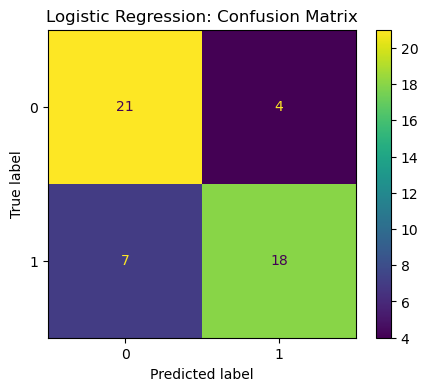

In [8]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax)
ax.set_title("Logistic Regression: Confusion Matrix")
plt.show()

## Part 4. First neural network

We now train a simple **multilayer perceptron (MLP)**.

Architecture:
- input layer: 100 features
- hidden layer: 20 neurons
- output layer: binary classification

A hidden layer allows the network to learn **nonlinear combinations** of features.

In [9]:

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(20,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test)
y_prob_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

print("MLP Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 4))
print("MLP ROC AUC:", round(roc_auc_score(y_test, y_prob_mlp), 4))

MLP Accuracy: 0.78
MLP ROC AUC: 0.8256


In [10]:

print("Classification report: MLP")
print(classification_report(y_test, y_pred_mlp))

Classification report: MLP
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        25
           1       0.82      0.72      0.77        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50



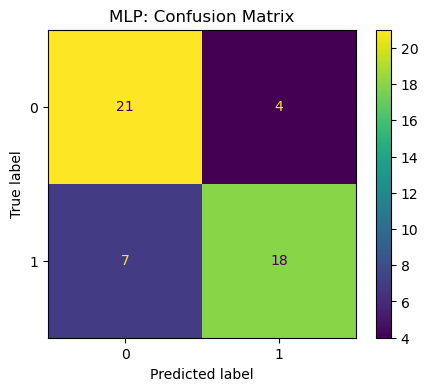

In [11]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, ax=ax)
ax.set_title("MLP: Confusion Matrix")
plt.show()

## Part 5. Compare ROC curves

ROC curves show how the true positive rate and false positive rate change as the threshold changes.

A higher AUC usually indicates better ranking ability.

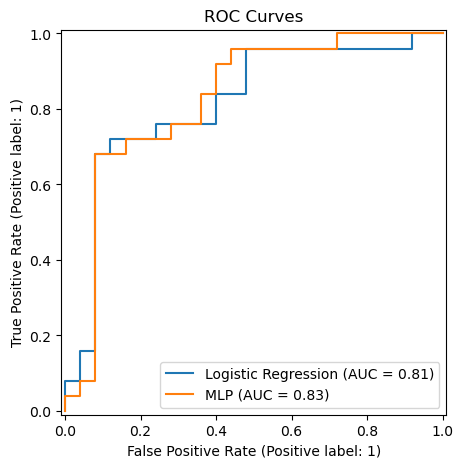

In [12]:

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_mlp, ax=ax, name="MLP")
ax.set_title("ROC Curves")
plt.show()

## Part 6. Why scaling matters

Neural networks are usually very sensitive to the scale of the inputs.

Below, we intentionally fit an MLP **without scaling** and compare the result.

In [13]:

mlp_no_scaling = MLPClassifier(
    hidden_layer_sizes=(20,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RANDOM_STATE
)

mlp_no_scaling.fit(X_train, y_train)

y_pred_no_scale = mlp_no_scaling.predict(X_test)
y_prob_no_scale = mlp_no_scaling.predict_proba(X_test)[:, 1]

print("MLP without scaling Accuracy:", round(accuracy_score(y_test, y_pred_no_scale), 4))
print("MLP without scaling ROC AUC:", round(roc_auc_score(y_test, y_prob_no_scale), 4))

MLP without scaling Accuracy: 0.76
MLP without scaling ROC AUC: 0.8448


### Check your understanding

1. Did the unscaled model perform worse, about the same, or better?
2. Why can large differences in feature magnitudes make training harder?
3. In real omics datasets, would scaling usually be important?

## Part 7. Inspect the loss curve

During training, the model tries to reduce a loss function.  
For `MLPClassifier`, we can inspect `loss_curve_`.

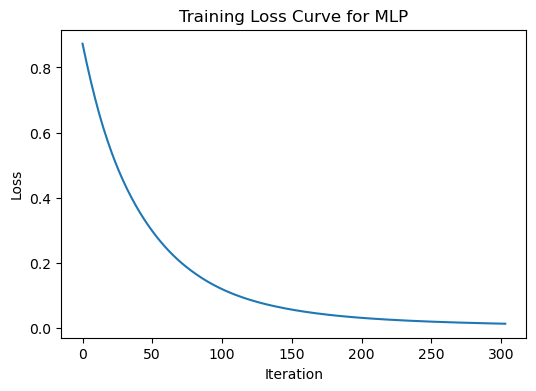

In [14]:

trained_mlp = mlp_pipeline.named_steps["model"]

plt.figure(figsize=(6, 4))
plt.plot(trained_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve for MLP")
plt.show()

### Interpretation questions

1. Is the loss generally decreasing?
2. Does it flatten out?
3. If the loss is noisy, what might that indicate?

## Part 8. Try a larger network

Now let us compare a few architectures.

We will test:
- `(5,)`
- `(20,)`
- `(50,)`
- `(50, 20)`

Then we will compare training and test accuracy.

**Important idea:**  
A larger network can fit more complex patterns, but it can also overfit.

In [15]:

architectures = [(5,), (20,), (50,), (50, 20)]
results = []

for arch in architectures:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    pipe.fit(X_train, y_train)

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)
    test_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    results.append({
        "architecture": str(arch),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "test_auc": test_auc
    })

results_df = pd.DataFrame(results)
results_df

,architecture,train_accuracy,test_accuracy,test_auc
0,"(5,)",0.986667,0.68,0.7264
1,"(20,)",1.000000,0.78,0.8256
2,"(50,)",1.000000,0.72,0.7520
3,"(50, 20)",1.000000,0.64,0.7280


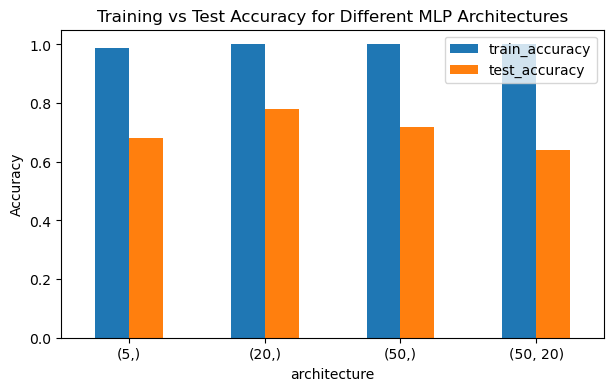

In [16]:

results_df.plot(x="architecture", y=["train_accuracy", "test_accuracy"], kind="bar", figsize=(7, 4))
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy for Different MLP Architectures")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Look for the following patterns:

- **Underfitting**: both training and test accuracy are low
- **Good fit**: both are reasonably high and similar
- **Overfitting**: training accuracy is much higher than test accuracy

## Part 9. Regularization

In `MLPClassifier`, the parameter `alpha` controls L2 regularization strength.

Larger `alpha` means:
- more penalty on large weights,
- simpler model,
- often better generalization if overfitting is present.

Let us test several values.

In [ ]:

alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1]
reg_results = []

for a in alphas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(50,),
            activation="relu",
            solver="adam",
            alpha=a,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    pipe.fit(X_train, y_train)

    reg_results.append({
        "alpha": a,
        "train_accuracy": pipe.score(X_train, y_train),
        "test_accuracy": pipe.score(X_test, y_test),
        "test_auc": roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    })

reg_results_df = pd.DataFrame(reg_results)
reg_results_df

### Reflection

1. As regularization increases, what happens to training accuracy?
2. Did test accuracy improve for any value of `alpha`?
3. Why might a little regularization help?

## Part 10. A small bioinformatics-style interpretation exercise

Suppose you are trying to classify:
- **tumor** vs **normal** samples
- based on 10,000 genes
- with only 150 patients

Answer these questions in words:

1. Why is this a difficult learning problem?
2. Why is feature scaling important?
3. Why might a neural network overfit?
4. Why should you compare against logistic regression first?
5. If your neural network gets 100% training accuracy but much lower test accuracy, what does that suggest?

## Part 11. Student exercises

Complete the following exercises by editing or adding code cells below.

### Exercise 1
Change the number of informative features in `make_classification` from 15 to 5.  
Retrain logistic regression and the MLP.  
What happens?

### Exercise 2
Change the class separation parameter `class_sep` from 1.2 to 0.5.  
How does this affect performance?

### Exercise 3
Try two additional MLP architectures of your choice.  
Which one gives the best test ROC AUC?

### Exercise 4
Increase the number of samples from 200 to 1000.  
Does the neural network benefit from having more data?

### Exercise 5
Write 3–5 sentences comparing logistic regression and MLP for this task.

## Part 12. Short-answer questions for the lab report

Answer these in complete sentences.

1. What is the benefit of using a hidden layer?
2. Why is ReLU commonly used in hidden layers?
3. Why is scaling especially important for neural networks?
4. What evidence would suggest overfitting?
5. In this lab, did the MLP clearly outperform logistic regression? Why or why not?
6. In a real bioinformatics problem, what additional precautions would you take before trusting a neural-network result?

## Part 13. Key takeaways

- Neural networks can model **nonlinear relationships**.
- A simple MLP can be trained easily with `scikit-learn`.
- **Scaling is critical** for neural networks.
- Bigger models are not always better.
- Always compare with a **baseline model**.
- In bioinformatics, high-dimensional data and small sample sizes make **overfitting** a major concern.

---

## Advanced topics for later

- multiclass classification,
- multilabel classification,
- feature selection before neural networks,
- nested cross-validation,
- PyTorch or TensorFlow,
- interpretation methods such as permutation importance or SHAP.